In [82]:
import cv2
import time
from insightface.app import FaceAnalysis
from matplotlib import pyplot as plt

app = FaceAnalysis()
어떤 모델 쓸지 설정
app.prepare()
-> 실제 모델 다운로드, ONNX 모델 로드, detector 초기화, recognition 초기화

In [83]:
app = FaceAnalysis(
    providers=['CPUExecutionProvider']
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

### test.jpg 이미지 읽기

In [169]:
img = cv2.imread("../images/test15.jpg")

 ### detection 시간 측정
 - 얼굴 검출, landmark 추출, embedding 생성 얼굴 개수 측정
 - detection 시간 측정

In [170]:
start = time.perf_counter()
faces = app.get(img)
end = time.perf_counter()

face.bbox -> [x1,y1,x2,y2] 형태의 얼굴 좌표 반환
- 왼쪽 위(100,50)
- 오른쪽 아래(300,280)
박스라는 의미



In [171]:
for face in faces:
    box = face.bbox.astype(int)
    x1,y1,x2,y2=box
    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

얼굴 주변에 초록색 사각형 생성

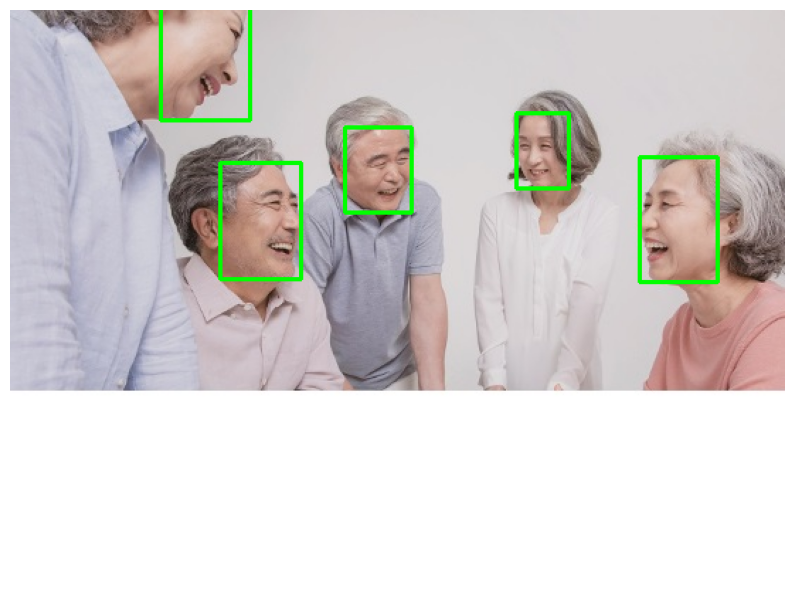

In [172]:
from matplotlib import pyplot as plt
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

### 검출된 얼굴 수 및 소요 시간 결과 출력

In [173]:
print("검출된 얼굴 수:", len(faces))
latency_ms = (end-start) * 1000
latency_sec = latency_ms / 1000
print(f"걸린 시간      : {latency_ms:.2f} ms ({latency_sec:.2f} sec)")

검출된 얼굴 수: 5
걸린 시간      : 7643.65 ms (7.64 sec)
